In [68]:
import numpy as np
import pandas as pd

# 2.2 data preparation

## load dataset

In [69]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [70]:
df = pd.read_csv('data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fixed of column name

In [71]:
# dataset er column name gulay jhamela eta thik korbo

df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [72]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fix of values

In [73]:
# column name fixed. ekhon value gula fix kora lagbe.
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [74]:
df.dtypes == 'str'

make                 False
model                False
year                 False
engine_fuel_type     False
engine_hp            False
engine_cylinders     False
transmission_type    False
driven_wheels        False
number_of_doors      False
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [75]:
df.dtypes[df.dtypes == 'str']

Series([], dtype: object)

In [76]:
# upore je dataframe paisi tar make,model,... eigula hoilo index and str,str,... eigula hoilo value.
# index gulare niya list e convert korbo jate loop chalaite pari.


strings = df.dtypes[df.dtypes == 'str'].index.tolist() # .tolist()  diye list e convert korlam

strings

[]

In [77]:
for x in strings:
    df[x] = df[x].str.lower().str.replace(' ', '_')

In [78]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [79]:
# awesome. column names and values all are fixed.

# 2.3 Exploratory data analysis

In [80]:
# first amader protita column e koyta unique value ase and ki ki(minimum 5 ta) check korte hobe.
# numerical and categorical both column check korte hobe. this is a part of eda. 

for x in df.columns:
    print(x)
    print(df[x].unique()[:5])
    print(df[x].nunique())
    print('-------------------')
    print()

make
['BMW' 'Audi' 'FIAT' 'Mercedes-Benz' 'Chrysler']
48
-------------------

model
['1 Series M' '1 Series' '100' '124 Spider' '190-Class']
915
-------------------

year
[2011 2012 2013 1992 1993]
28
-------------------

engine_fuel_type
['premium unleaded (required)' 'regular unleaded'
 'premium unleaded (recommended)' 'flex-fuel (unleaded/E85)' 'diesel']
10
-------------------

engine_hp
[335. 300. 230. 320. 172.]
356
-------------------

engine_cylinders
[ 6.  4.  5.  8. 12.]
9
-------------------

transmission_type
['MANUAL' 'AUTOMATIC' 'AUTOMATED_MANUAL' 'DIRECT_DRIVE' 'UNKNOWN']
5
-------------------

driven_wheels
['rear wheel drive' 'front wheel drive' 'all wheel drive'
 'four wheel drive']
4
-------------------

number_of_doors
[ 2.  4.  3. nan]
3
-------------------

market_category
['Factory Tuner,Luxury,High-Performance' 'Luxury,Performance'
 'Luxury,High-Performance' 'Luxury' 'Performance']
71
-------------------

vehicle_size
['Compact' 'Midsize' 'Large']
3
-------------

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


<Axes: xlabel='msrp', ylabel='Count'>

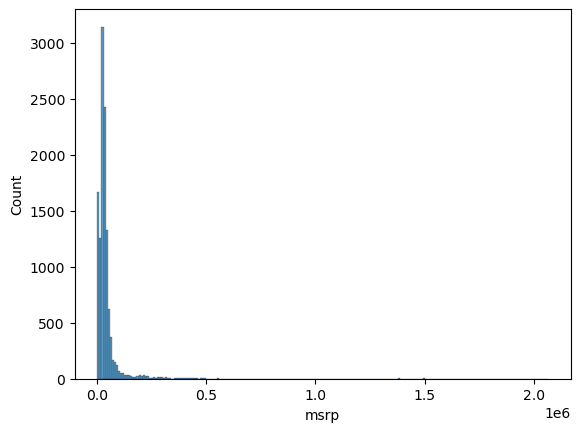

In [83]:
sns.histplot(data=df, x='msrp')

<Axes: xlabel='msrp', ylabel='Count'>

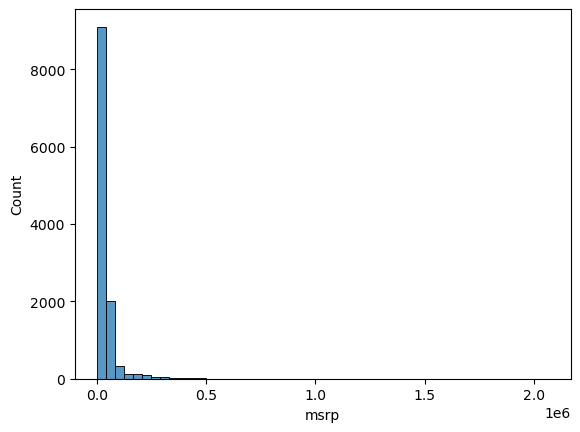

In [84]:
sns.histplot(data = df, x='msrp', bins=50)

# nicher graph ta dekho x axis e msrp dewa ase 1e6 diye. mane 1 er por 6 ta zero, mane 10 lakh. 
# that means ei graph e 0, 5 lakh, 10 lakh, 15 lakh, 20 lakh dollar er range ase. 

# nicher graph ta dekhe bojha jay 0 theke 3 lakh er moddhe density beshi.

<Axes: xlabel='msrp', ylabel='Count'>

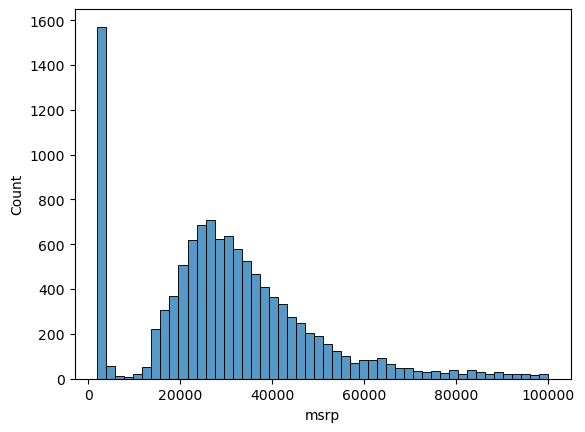

In [85]:
# ekhn ami condition diye price range komaya dibo.
sns.histplot(data = df[df.msrp < 100000], x='msrp', bins=50)

In [86]:
# uporer graph theke bujhlam eta right skewed. and linear regression er jonne bell shaped (normal distribution) data dorkar.

# and etar jonne amader log-normal distribution apply korte hobe.

# nicher code ta just sample ekta code. protita value 10x kore beshi. parthokko 99, 999, 9999,... but jokhon log e convert kore nichi tokhon difference onek kome gese. 

np.log([1, 100, 1000, 10000])

array([0.        , 4.60517019, 6.90775528, 9.21034037])

In [87]:
# but log er vitore 0 thakle error dibe. so, amra log1p use korbo. log1p mane log(1+x). so, 0 thakleo sheta 1 hoye jabe and error dibe na.

np.log1p([1, 100, 1000, 10000])

array([0.69314718, 4.61512052, 6.90875478, 9.21044037])

<Axes: xlabel='msrp', ylabel='Count'>

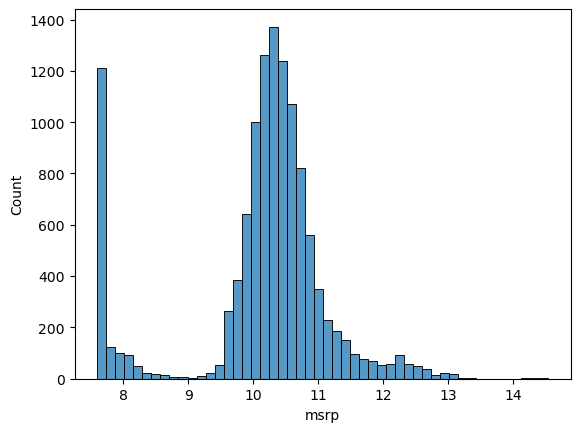

In [88]:
# ekhon msrp er value gular difference jehetu onek beshi tai ami log1p kore felbo.
# log1p use korle duita jinish hoy. 1. data ta normal distribution e convert hoye jabe. 2. data er difference onek choto hoye jabe.

price_log = np.log1p(df.msrp)

sns.histplot(data = price_log, bins=50)

In [89]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 - the validation framework

In [90]:
# ekhn full dataset ke train, validation and test e split korte hobe. 60% train, 20% validation and 20% test.
# but first e suffle kore newa lagbe karon dataset kono ekta feature er upor sorted thakte pare.
# eta numpy, pandas and sklearn diye kora jay. numpy fast, pandas easy and sklearn fast + easy. but numpy er theke khub ekta easy na. so ami always numpy diyei korbo.

# so steps are: 1. suffle, 2. size calculation, 3. split    -> split korai main target but split korar jonnei suffle and size calculation korte hobe.


# and then finally feature matrix(input) and target variable(output) banabo from train data.

pass

### dataset shuffle 

In [101]:
# etar maddhome dataset e total row number dekhte pabo.
n = len(df)

n

11914

In [92]:
# স্টেপ ১: Shuffle (পুরো ডেটাসেট শাফেল করা)
np.random.seed(2)

idx = np.arange(len(df)) # dtaset e total 11914 ta row ase. idx er moddhe 0 to 11913 porjonto serially number gula numpy array hishebe ase.

np.random.shuffle(idx) # ekhon idx er moddhe 0 to 11913 porjonto number gula random order e ase. mane shafle kora hoise.

df_shuffled = df.iloc[idx].reset_index(drop=True)  # ekhon iloc diye dataset e shafle kora index gula diye row gula select kora hoise. and reset_index diye index 0 theke start kora hoise. drop=True means main dataset er index ei change kora hoilo.

### dataset er size calculation

In [93]:
n = len(df_shuffled)

n

11914

In [94]:
# ekhon 11914 ta row er 20 percent validation, 20 percent test and baki rows(nearly 60 percent) train e split kora hobe.
# ei code gulay split kora hoy nai. just 20 percent e koyta row hoy shei number ta store kora hoise. ei number split e kaje lagbe.

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

### split

In [95]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [96]:
df_train = df_shuffled.iloc[:n_train]  # prothom 7150(0 to 7149) ta row train data hishebe nilam

df_val = df_shuffled.iloc[n_train : n_train + n_val] # 7150 : 9532(7150 + 2382) ta row validation data hishebe nilam 

df_test = df_shuffled.iloc[n_train + n_val :] # # 9532 : 11914(9532 + 2382) ta row test data hishebe nilam

### feature matrix and target variable

In [97]:
# first e train, validation and test dataset theke target variable(y) msrp alada korbo.

df_train['msrp']

0        14410
1        19685
2        19795
3         2000
4        56260
         ...  
7145     54900
7146     29215
7147     34675
7148    303300
7149     37820
Name: msrp, Length: 7150, dtype: int64

In [98]:
# upore dekhtei partesi ekta column select korle oita pandas series return kore and index ow thake. index amar kaje lagbe na. just values gula kaje lagbe. so, ami to_numpy() use kore numpy array e convert korbo.

df_train['msrp'].to_numpy()

array([ 14410,  19685,  19795, ...,  34675, 303300,  37820], shape=(7150,))

In [99]:
# now eda te dekhsi msrp er value gulare normal distribution e convert korar jonne log transformation korte hobe.

# y_train, y_val, y_test er moddhe msrp(target variable, y) er log transformed value store ase.

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [100]:
# ekhon main dataset(df_train, df_val, df_test) theke msrp column ta delete kore dibo. taholei ami feature matrix(input) pabo.

# delete korar por df_train, df_val, df_test ei holo feature matrix.

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']